<a href="https://colab.research.google.com/github/jorgefbarreiros/codes/blob/main/myrank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEADY STATE ================

r_ss           =  0.041667
R_ss           =  1.041667
Y_ss           =  1.000000
C_ss           =  1.000000
N_ss           =  1.000000
w_ss           =  0.833333
mc_ss          =  0.833333
div_ss         =  0.166667
tax_ss         =  0.208333
chi            =  0.833333
B_g_ss         =  5.000000


Newton iter 00 | max residual = 9.455e-03
Newton iter 01 | max residual = 4.726e-03
Newton iter 02 | max residual = 2.362e-03
Newton iter 03 | max residual = 1.181e-03
Newton iter 04 | max residual = 5.905e-04
Newton iter 05 | max residual = 2.952e-04
Newton iter 06 | max residual = 1.476e-04
Newton iter 07 | max residual = 7.381e-05
Newton iter 08 | max residual = 3.691e-05
Newton iter 09 | max residual = 1.845e-05
Newton iter 10 | max residual = 9.226e-06
Newton iter 11 | max residual = 4.613e-06
Newton iter 12 | max residual = 2.307e-06
Newton iter 13 | max residual = 1.153e-06
Newton iter 14 | max residual = 5.766e-07
Newton iter 15 | max r

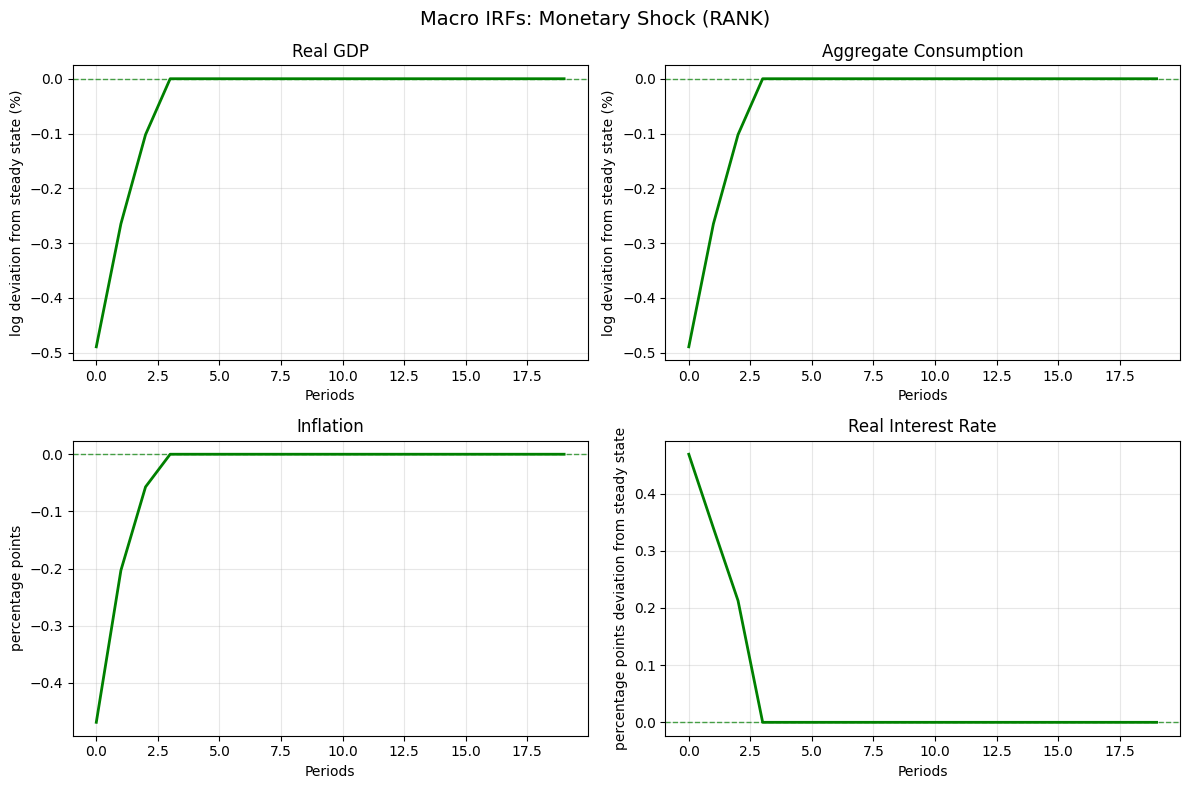

Saved: figures_rank_nk/additional_rank_objects.png


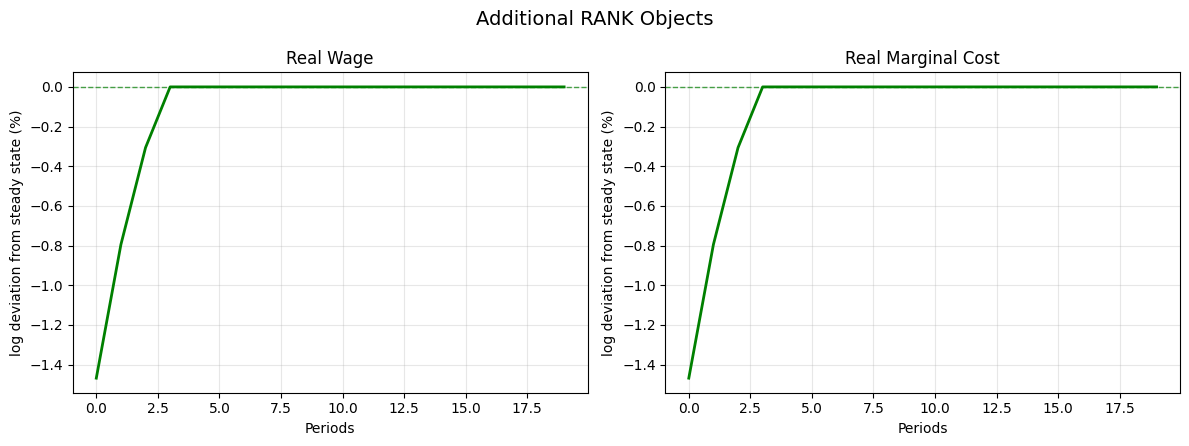

Saved: figures_rank_nk/euler_residual_rank.png


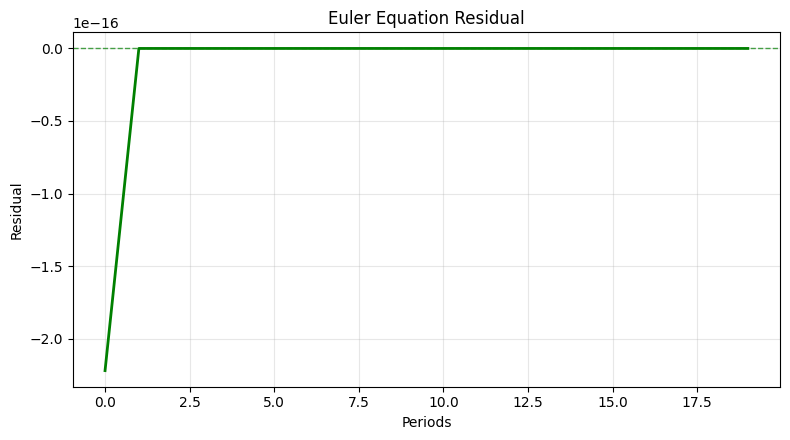


All PNGs saved in: figures_rank_nk

Diagnostics:
  max |goods residual| : 9.009994528241805e-09
  max |NKPC residual|  : 3.3792159400553023e-09
  max |Euler residual| : 2.220446049250313e-16
  max |asset residual| : 0.0


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass


# =========================================================
# 0. OUTPUT FOLDER
# =========================================================
OUTPUT_DIR = "figures_rank_nk"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PLOT_COLOR = "green"


def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved: {path}")


# =========================================================
# 1. PARAMETERS / CONTAINERS
# =========================================================
@dataclass
class RANKParams:
    beta: float = 0.96
    sigma: float = 2.0


@dataclass
class NKParams:
    A_ss: float = 1.0
    epsilon_p: float = 6.0
    theta_p: float = 0.75
    phi_n: float = 1.0

    phi_pi: float = 1.5
    phi_y: float = 0.10

    B_g_ss: float = 5.0

    T: int = 20
    newton_max_iter: int = 25
    newton_tol: float = 1e-8
    newton_step: float = 1e-5
    damp: float = 0.50


@dataclass
class SteadyState:
    r: float
    R: float
    Y: float
    C: float
    N: float
    w: float
    mc: float
    div: float
    tax: float
    chi: float
    i_nom: float
    pi: float
    B_g: float


@dataclass
class TransitionResult:
    Y: np.ndarray
    C: np.ndarray
    N: np.ndarray
    w: np.ndarray
    mc: np.ndarray
    pi: np.ndarray
    i_nom: np.ndarray
    r_real: np.ndarray
    div: np.ndarray
    taxes: np.ndarray
    goods_residual: np.ndarray
    nkpc_residual: np.ndarray
    euler_residual: np.ndarray
    asset_mkt_residual: np.ndarray


# =========================================================
# 2. NK HELPERS
# =========================================================
def nk_kappa(beta, theta_p, epsilon_p, phi_n):
    return ((1.0 - theta_p) * (1.0 - beta * theta_p) / theta_p) * (1.0 + phi_n)


def markup_ss(epsilon_p):
    return epsilon_p / (epsilon_p - 1.0)


# =========================================================
# 3. STEADY STATE
# =========================================================
def solve_steady_state(rank: RANKParams, nk: NKParams):
    Y_ss = 1.0
    C_ss = 1.0
    N_ss = Y_ss / nk.A_ss

    mu_p = markup_ss(nk.epsilon_p)
    mc_ss = 1.0 / mu_p
    w_ss = mc_ss * nk.A_ss
    div_ss = Y_ss - w_ss * N_ss

    # Standard RANK steady state: Euler pins down R = 1 / beta
    R_ss = 1.0 / rank.beta
    r_ss = R_ss - 1.0

    tax_ss = r_ss * nk.B_g_ss

    # Labor block
    chi = w_ss / (N_ss ** nk.phi_n * C_ss ** rank.sigma)

    ss = SteadyState(
        r=r_ss,
        R=R_ss,
        Y=Y_ss,
        C=C_ss,
        N=N_ss,
        w=w_ss,
        mc=mc_ss,
        div=div_ss,
        tax=tax_ss,
        chi=chi,
        i_nom=r_ss,
        pi=0.0,
        B_g=nk.B_g_ss,
    )
    return ss


# =========================================================
# 4. RANK HOUSEHOLDS ALONG A TRANSITION
# =========================================================
def rank_consumption_path(rank: RANKParams, ss: SteadyState, R_real):
    """
    Representative household Euler equation:
        C_t^(-sigma) = beta * R_t * C_{t+1}^(-sigma)

    Terminal condition:
        C_T = C_ss
    """
    T = len(R_real)
    sigma = rank.sigma
    beta = rank.beta

    C = np.zeros(T)
    C_terminal = ss.C

    C_next = C_terminal
    for t in range(T - 1, -1, -1):
        C[t] = (beta * R_real[t]) ** (-1.0 / sigma) * C_next
        C[t] = max(C[t], 1e-12)
        C_next = C[t]

    return C


# =========================================================
# 5. TRANSITION EQUILIBRIUM
# =========================================================
def pack_x(yhat, pi):
    return np.concatenate([yhat, pi])


def unpack_x(x, T):
    yhat = x[:T]
    pi = x[T:]
    return yhat, pi


def equilibrium_residuals(x, rank: RANKParams, nk: NKParams, ss: SteadyState,
                          A_path, mp_shock, B_g_path):
    T = nk.T
    beta = rank.beta
    kappa = nk_kappa(beta, nk.theta_p, nk.epsilon_p, nk.phi_n)

    yhat, pi = unpack_x(x, T)
    Y = ss.Y * np.exp(yhat)

    # terminal anchor
    pi_lead = np.zeros(T)
    pi_lead[:-1] = pi[1:]
    pi_lead[-1] = 0.0

    i_nom = (
        (1.0 + ss.i_nom)
        * ((1.0 + np.maximum(pi, -0.99)) ** nk.phi_pi)
        * ((Y / ss.Y) ** nk.phi_y)
        * np.exp(mp_shock)
        - 1.0
    )
    i_nom = np.maximum(i_nom, -0.999)

    R_real = (1.0 + i_nom) / (1.0 + pi_lead)
    r_real = R_real - 1.0

    C = rank_consumption_path(rank, ss, R_real)

    N = Y / A_path
    w = ss.chi * (N ** nk.phi_n) * (C ** rank.sigma)
    mc = w / A_path
    mc_hat = np.log(mc / ss.mc)

    goods_res = Y - C
    nkpc_res = pi - beta * pi_lead - kappa * mc_hat

    return np.concatenate([goods_res, nkpc_res])


def finite_diff_jacobian(fun, x, h=1e-5):
    n = len(x)
    f0 = fun(x)
    m = len(f0)
    J = np.zeros((m, n))
    for j in range(n):
        xp = x.copy()
        xm = x.copy()
        xp[j] += h
        xm[j] -= h
        fp = fun(xp)
        fm = fun(xm)
        J[:, j] = (fp - fm) / (2.0 * h)
    return f0, J


def solve_transition(rank: RANKParams, nk: NKParams, ss: SteadyState,
                     A_path=None, mp_shock=None, B_g_path=None, verbose=True):
    T = nk.T

    if A_path is None:
        A_path = np.ones(T) * nk.A_ss
    if mp_shock is None:
        mp_shock = np.zeros(T)
    if B_g_path is None:
        B_g_path = np.ones(T) * ss.B_g

    x = pack_x(np.zeros(T), np.zeros(T))

    def fun_local(xx):
        return equilibrium_residuals(xx, rank, nk, ss, A_path, mp_shock, B_g_path)

    for it in range(nk.newton_max_iter):
        fval, J = finite_diff_jacobian(fun_local, x, h=nk.newton_step)
        err = np.max(np.abs(fval))
        if verbose:
            print(f"Newton iter {it:02d} | max residual = {err:.3e}")

        if err < nk.newton_tol:
            break

        dx = np.linalg.solve(J, -fval)
        x = x + nk.damp * dx

    yhat, pi = unpack_x(x, T)
    Y = ss.Y * np.exp(yhat)

    pi_lead = np.zeros(T)
    pi_lead[:-1] = pi[1:]
    pi_lead[-1] = 0.0

    i_nom = (
        (1.0 + ss.i_nom)
        * ((1.0 + np.maximum(pi, -0.99)) ** nk.phi_pi)
        * ((Y / ss.Y) ** nk.phi_y)
        * np.exp(mp_shock)
        - 1.0
    )
    i_nom = np.maximum(i_nom, -0.999)

    R_real = (1.0 + i_nom) / (1.0 + pi_lead)
    r_real = R_real - 1.0

    C = rank_consumption_path(rank, ss, R_real)

    N = Y / A_path
    w = ss.chi * (N ** nk.phi_n) * (C ** rank.sigma)
    mc = w / A_path
    div = Y - w * N
    taxes = r_real * B_g_path

    goods_res = Y - C
    kappa = nk_kappa(rank.beta, nk.theta_p, nk.epsilon_p, nk.phi_n)
    nkpc_res = pi - rank.beta * pi_lead - kappa * np.log(mc / ss.mc)

    euler_res = np.zeros(T)
    euler_res[:-1] = (
        C[:-1] ** (-rank.sigma)
        - rank.beta * R_real[:-1] * C[1:] ** (-rank.sigma)
    )
    euler_res[-1] = C[-1] - ss.C

    # In RANK, representative household holds all government debt
    asset_res = np.zeros(T)

    return TransitionResult(
        Y=Y,
        C=C,
        N=N,
        w=w,
        mc=mc,
        pi=pi,
        i_nom=i_nom,
        r_real=r_real,
        div=div,
        taxes=taxes,
        goods_residual=goods_res,
        nkpc_residual=nkpc_res,
        euler_residual=euler_res,
        asset_mkt_residual=asset_res,
    )


# =========================================================
# 6. PRINTING / PLOTTING
# =========================================================
def print_ss(ss: SteadyState):
    print("\n================ STEADY STATE ================\n")
    print(f"r_ss           = {ss.r: .6f}")
    print(f"R_ss           = {ss.R: .6f}")
    print(f"Y_ss           = {ss.Y: .6f}")
    print(f"C_ss           = {ss.C: .6f}")
    print(f"N_ss           = {ss.N: .6f}")
    print(f"w_ss           = {ss.w: .6f}")
    print(f"mc_ss          = {ss.mc: .6f}")
    print(f"div_ss         = {ss.div: .6f}")
    print(f"tax_ss         = {ss.tax: .6f}")
    print(f"chi            = {ss.chi: .6f}")
    print(f"B_g_ss         = {ss.B_g: .6f}")
    print("\n=============================================\n")


def plot_macro_irfs(ss: SteadyState, tr: TransitionResult):
    t = np.arange(len(tr.Y))

    gdp_irf = 100.0 * np.log(tr.Y / ss.Y)
    c_irf = 100.0 * np.log(tr.C / ss.C)
    infl_irf = 100.0 * tr.pi
    r_irf = 100.0 * (tr.r_real - ss.r)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    series_list = [
        (gdp_irf, "Real GDP", "log deviation from steady state (%)"),
        (c_irf, "Aggregate Consumption", "log deviation from steady state (%)"),
        (infl_irf, "Inflation", "percentage points"),
        (r_irf, "Real Interest Rate", "percentage points deviation from steady state"),
    ]

    for ax, (series, title, ylabel) in zip(axes, series_list):
        ax.plot(t, series, linewidth=2.0, color=PLOT_COLOR)
        ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7, color=PLOT_COLOR)
        ax.set_title(title)
        ax.set_xlabel("Periods")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    fig.suptitle("Macro IRFs: Monetary Shock (RANK)", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "macro_irfs_monetary_rank.png")
    plt.show()


def plot_additional_rank_objects(ss: SteadyState, tr: TransitionResult):
    t = np.arange(len(tr.Y))

    wage_irf = 100.0 * np.log(tr.w / ss.w)
    mc_irf = 100.0 * np.log(tr.mc / ss.mc)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(t, wage_irf, linewidth=2.0, color=PLOT_COLOR)
    axes[0].axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7, color=PLOT_COLOR)
    axes[0].set_title("Real Wage")
    axes[0].set_xlabel("Periods")
    axes[0].set_ylabel("log deviation from steady state (%)")
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, mc_irf, linewidth=2.0, color=PLOT_COLOR)
    axes[1].axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7, color=PLOT_COLOR)
    axes[1].set_title("Real Marginal Cost")
    axes[1].set_xlabel("Periods")
    axes[1].set_ylabel("log deviation from steady state (%)")
    axes[1].grid(alpha=0.3)

    fig.suptitle("Additional RANK Objects", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "additional_rank_objects.png")
    plt.show()


def plot_euler_residual(ss: SteadyState, tr: TransitionResult):
    t = np.arange(len(tr.Y))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t, tr.euler_residual, linewidth=2.0, color=PLOT_COLOR)
    ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7, color=PLOT_COLOR)
    ax.set_title("Euler Equation Residual")
    ax.set_xlabel("Periods")
    ax.set_ylabel("Residual")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    save_figure(fig, "euler_residual_rank.png")
    plt.show()


# =========================================================
# 7. RUN
# =========================================================
rank = RANKParams(
    beta=0.96,
    sigma=2.0,
)

nk = NKParams(
    A_ss=1.0,
    epsilon_p=6.0,
    theta_p=0.75,
    phi_n=1.0,
    phi_pi=1.5,
    phi_y=0.10,
    B_g_ss=5.0,
    T=20,
    newton_max_iter=25,
    newton_tol=1e-8,
    newton_step=1e-5,
    damp=0.50,
)

# -------------------------
# Steady state
# -------------------------
ss = solve_steady_state(rank, nk)
print_ss(ss)

# -------------------------
# Monetary shock only
# -------------------------
T = nk.T
A_path = np.ones(T) * nk.A_ss
B_g_path = np.ones(T) * nk.B_g_ss

mp_shock = np.zeros(T)
mp_shock[0] = 0.010
mp_shock[1] = 0.006
mp_shock[2] = 0.003

tr_monetary = solve_transition(
    rank, nk, ss,
    A_path=A_path,
    mp_shock=mp_shock,
    B_g_path=B_g_path,
    verbose=True
)

plot_macro_irfs(ss, tr_monetary)
plot_additional_rank_objects(ss, tr_monetary)
plot_euler_residual(ss, tr_monetary)

print(f"\nAll PNGs saved in: {OUTPUT_DIR}\n")
print("Diagnostics:")
print("  max |goods residual| :", np.max(np.abs(tr_monetary.goods_residual)))
print("  max |NKPC residual|  :", np.max(np.abs(tr_monetary.nkpc_residual)))
print("  max |Euler residual| :", np.max(np.abs(tr_monetary.euler_residual)))
print("  max |asset residual| :", np.max(np.abs(tr_monetary.asset_mkt_residual)))